# 🧠 Brain Tumor MRI Classification using CNN 

## 2. Problem Statement

**What problem are we solving?**
Given a brain MRI scan, predict whether it shows a glioma tumor, a meningioma tumor, a
pituitary tumor, or no tumor at all.

**Why is this problem important?**
Manual MRI review is slow and requires an experienced radiologist. An automated CNN-based
screening tool can act as a fast, consistent first pass that flags likely tumor type (or
confirms no tumor is visible), helping prioritize cases and support — not replace — expert
diagnosis.

**Expected outcome:**
A trained CNN, selected after comparing multiple architectures and tuning its
hyperparameters, that classifies MRI scans into the 4 categories with strong accuracy, with
a full evaluation report on the held-out `Testing/` set.


## Setup — Imports

In [1]:
# ---- Core imports ----
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16, MobileNetV2, ResNet50

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, ConfusionMatrixDisplay)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import keras_tuner as kt   # pip install keras-tuner

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.21.0
GPU available: []


## Setup — Dataset paths (matches your VS Code folder structure)

In [9]:
# ---- Point this at your dataset location ----
DATA_DIR = "brain-tumor-data"
TRAIN_DIR = os.path.join(DATA_DIR, "Training")
TEST_DIR = os.path.join(DATA_DIR, "Testing")

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print("Classes found:", CLASS_NAMES)


Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 3. Data Exploration and Visualization (EDA)

### 3a. Build labeled DataFrames from the folder structure

In [10]:
def build_dataframe(directory, class_names):
    """Walk a Training/ or Testing/ folder and build a (filepath, label) DataFrame."""
    records = []
    for cls in class_names:
        cls_dir = os.path.join(directory, cls)
        for fname in os.listdir(cls_dir):
            records.append({"filepath": os.path.join(cls_dir, fname), "label": cls})
    return pd.DataFrame(records)

full_train_df = build_dataframe(TRAIN_DIR, CLASS_NAMES)
test_df = build_dataframe(TEST_DIR, CLASS_NAMES)

print("Full Training folder:", full_train_df.shape)
print("Testing folder:", test_df.shape)


Full Training folder: (5600, 2)
Testing folder: (1600, 2)


In [44]:
# Training set counts
train_counts = full_train_df.groupby("label").size().reset_index(name="train_count")

# Testing set counts
test_counts = test_df.groupby("label").size().reset_index(name="test_count")

print("Training class counts:\n", train_counts)
print("\nTesting class counts:\n", test_counts)


Training class counts:
         label  train_count
0      glioma         1400
1  meningioma         1400
2     notumor         1400
3   pituitary         1400

Testing class counts:
         label  test_count
0      glioma         400
1  meningioma         400
2     notumor         400
3   pituitary         400


C:\Users\Rudrakanta\AppData\Local\Temp\ipykernel_12256\3273771140.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=full_train_df, order=CLASS_NAMES, palette="viridis")


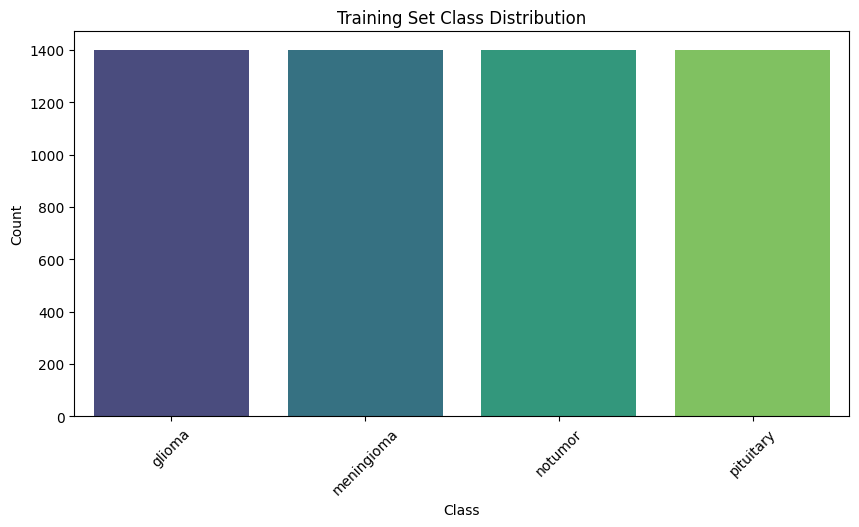

C:\Users\Rudrakanta\AppData\Local\Temp\ipykernel_12256\3273771140.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=test_df, order=CLASS_NAMES, palette="magma")


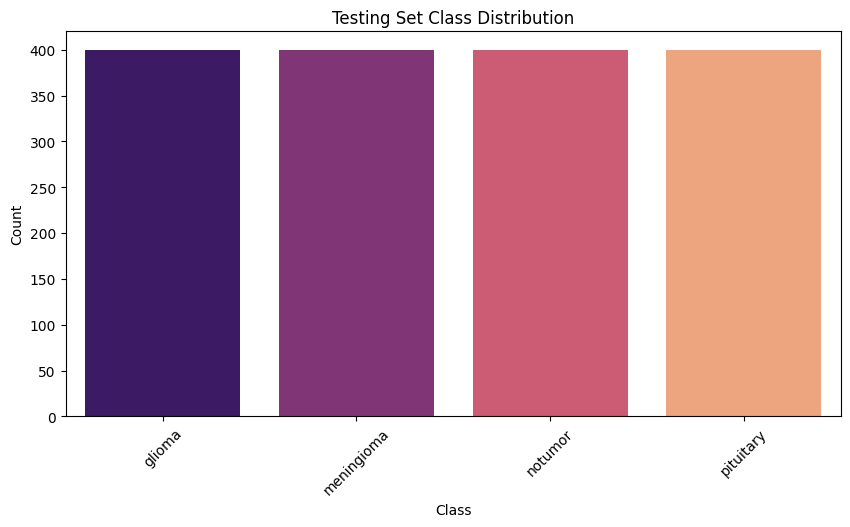

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Training set distribution ---
plt.figure(figsize=(10,5))
sns.countplot(x="label", data=full_train_df, order=CLASS_NAMES, palette="viridis")
plt.title("Training Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# --- Testing set distribution ---
plt.figure(figsize=(10,5))
sns.countplot(x="label", data=test_df, order=CLASS_NAMES, palette="magma")
plt.title("Testing Set Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [11]:
# ---- Split the Training folder into Train / Validation (stratified) ----
train_df, val_df = train_test_split(
    full_train_df,
    test_size=0.15,
    random_state=SEED,
    stratify=full_train_df["label"]
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)


Train: (4760, 2)
Val: (840, 2)
Test: (1600, 2)


### 3b. Class distribution — Training vs Validation vs Testing

            Train  Validation  Test
label                              
glioma       1190         210   400
meningioma   1190         210   400
notumor      1190         210   400
pituitary    1190         210   400


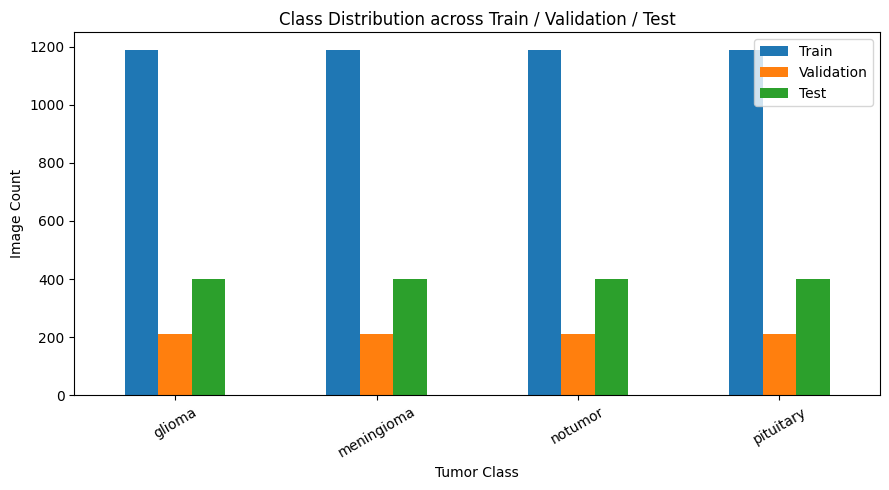

In [12]:
# ---- Class distribution across all 3 splits, side by side ----
dist_df = pd.DataFrame({
    "Train": train_df["label"].value_counts(),
    "Validation": val_df["label"].value_counts(),
    "Test": test_df["label"].value_counts()
}).reindex(CLASS_NAMES)

print(dist_df)

dist_df.plot(kind="bar", figsize=(9, 5))
plt.title("Class Distribution across Train / Validation / Test")
plt.xlabel("Tumor Class")
plt.ylabel("Image Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


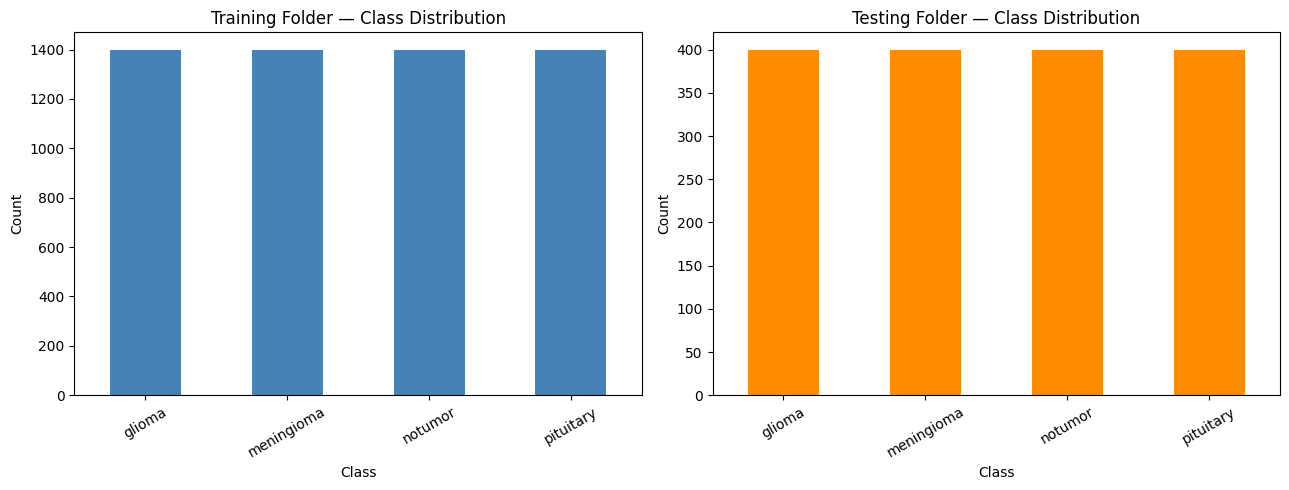

In [13]:
# ---- Class distribution: Training folder vs Testing folder specifically ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

full_train_df["label"].value_counts().reindex(CLASS_NAMES).plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Training Folder — Class Distribution")
axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)

test_df["label"].value_counts().reindex(CLASS_NAMES).plot(
    kind="bar", ax=axes[1], color="darkorange"
)
axes[1].set_title("Testing Folder — Class Distribution")
axes[1].set_xlabel("Class"); axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


### 3c. Sample images from each of the 4 classes (Training set)

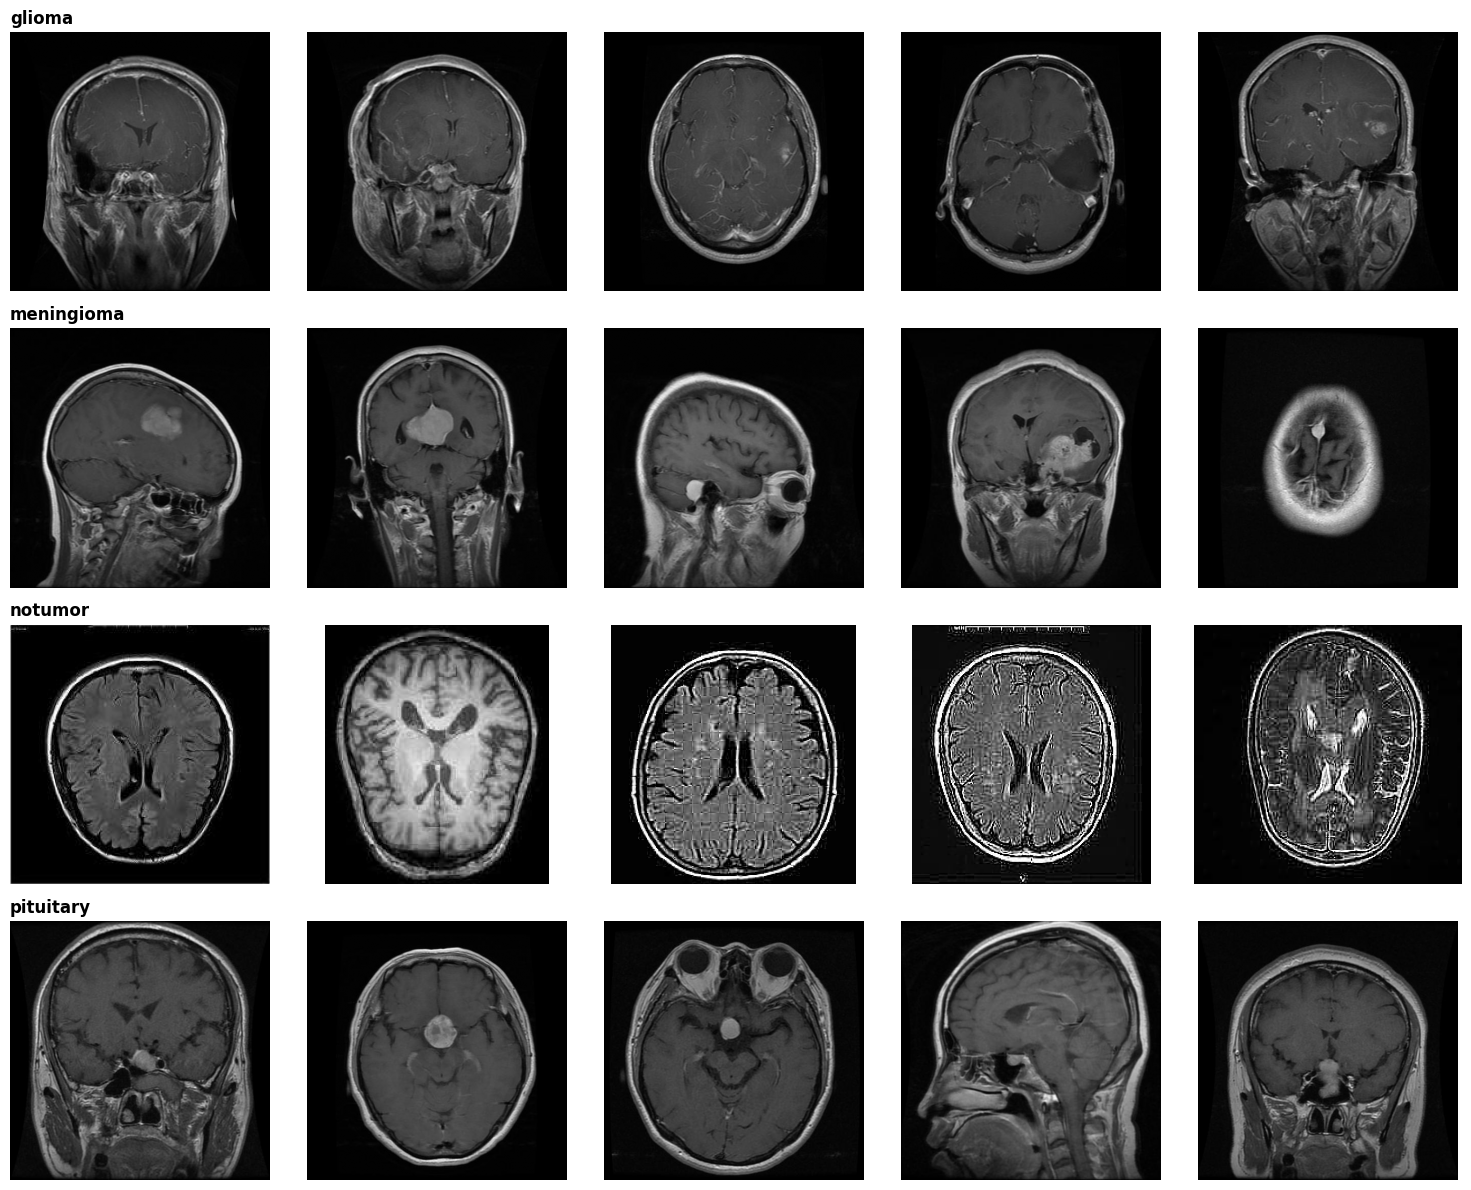

In [14]:
# ---- Visualize 5 sample images per class, from the Training data ----
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(15, 3 * NUM_CLASSES))

for row, cls in enumerate(CLASS_NAMES):
    cls_samples = train_df[train_df["label"] == cls].sample(5, random_state=SEED)
    for col, filepath in enumerate(cls_samples["filepath"]):
        img = Image.open(filepath)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
    axes[row, 0].set_title(cls, loc="left", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


**EDA takeaways:**
- All 4 classes are represented in both Training and Testing, including `notumor` this time.
- Class counts aren't perfectly balanced, so we use class weights during training.
- Images vary in raw size, so every image is resized to a fixed shape before modeling.


## 4. Data Preprocessing

In [57]:
import os
from PIL import Image

# Pick 5 random samples from training dataframe
sample_df = train_df.sample(5, random_state=42)

for idx, row in sample_df.iterrows():
    img_path = row["filepath"]
    img = Image.open(img_path)
    print(f"Class: {row['label']}, File: {os.path.basename(img_path)}, Original size: {img.size}")


Class: pituitary, File: Tr-pi_1168.jpg, Original size: (512, 512)
Class: pituitary, File: Tr-pi_1273.jpg, Original size: (512, 512)
Class: notumor, File: Tr-no_253.jpg, Original size: (630, 630)
Class: notumor, File: Tr-no_1232.jpg, Original size: (428, 417)
Class: meningioma, File: Tr-me_453.jpg, Original size: (306, 306)


Class: notumor, File: brain-tumor-data\Training\notumor\Tr-no_398.jpg, Original size: (215, 234)


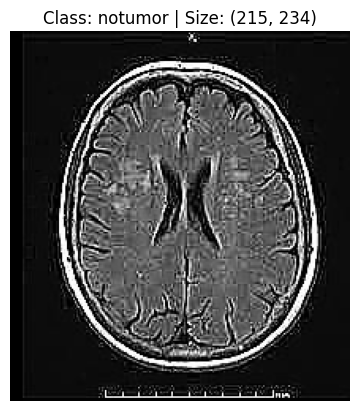

In [59]:
# Random one image visualize
import random
from PIL import Image
import matplotlib.pyplot as plt

# Pick one random sample from training dataframe
row = train_df.sample(1, random_state=random.randint(0,1000)).iloc[0]

img_path = row["filepath"]
img = Image.open(img_path)

print(f"Class: {row['label']}, File: {img_path}, Original size: {img.size}")

# Show the image
plt.imshow(img)
plt.title(f"Class: {row['label']} | Size: {img.size}")
plt.axis("off")
plt.show()


In [15]:
# ---- Preprocessing configuration ----
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Training generator: normalization + augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validation/Test generators: normalization only (no augmentation, for honest evaluation)
eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASS_NAMES, seed=SEED
)

val_generator = eval_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASS_NAMES, shuffle=False
)

test_generator = eval_datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", classes=CLASS_NAMES, shuffle=False
)

print(train_generator.class_indices)


Found 4760 validated image filenames belonging to 4 classes.
Found 840 validated image filenames belonging to 4 classes.
Found 1600 validated image filenames belonging to 4 classes.
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [16]:
# ---- Class weights, to compensate for any imbalance during training ----
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)


Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


## 5. CNN Model Building — Architecture Experiment (Bake-off)

Instead of picking one architecture on faith, we build and briefly train **5 candidates**
and compare their validation accuracy:

1. **Custom CNN v1** — a compact baseline built from scratch.
2. **Custom CNN v2** — deeper, with more filters and stronger regularization.
3. **Transfer Learning — VGG16** (frozen base).
4. **Transfer Learning — MobileNetV2** (frozen base).
5. **Transfer Learning — ResNet50** (frozen base).

Each is trained for a few epochs only — enough to see which architecture is worth
investing full training + hyperparameter tuning time into.


In [17]:
INPUT_SHAPE = (*IMG_SIZE, 3)

# ---- Candidate 1: Custom CNN v1 (compact baseline) ----
def build_custom_cnn_v1():
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(2, 2),
        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(2, 2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="custom_cnn_v1")
    return model


# ---- Candidate 2: Custom CNN v2 (deeper, more regularized) ----
def build_custom_cnn_v2():
    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="custom_cnn_v2")
    return model


# ---- Candidates 3-5: Transfer learning with different pretrained backbones ----
def build_transfer_model(base_model_class, name):
    base_model = base_model_class(input_shape=INPUT_SHAPE, include_top=False, weights="imagenet")
    base_model.trainable = False  # freeze pretrained weights for the bake-off

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name=name)
    return model, base_model


candidates = {
    "custom_cnn_v1": build_custom_cnn_v1(),
    "custom_cnn_v2": build_custom_cnn_v2(),
}

vgg16_model, vgg16_base = build_transfer_model(VGG16, "vgg16_transfer")
mobilenet_model, mobilenet_base = build_transfer_model(MobileNetV2, "mobilenetv2_transfer")
resnet_model, resnet_base = build_transfer_model(ResNet50, "resnet50_transfer")

candidates["vgg16_transfer"] = vgg16_model
candidates["mobilenetv2_transfer"] = mobilenet_model
candidates["resnet50_transfer"] = resnet_model

for name, model in candidates.items():
    print(f"{name}: {model.count_params():,} params")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 233s 4us/step


C:\Users\Rudrakanta\AppData\Local\Temp\ipykernel_12256\3788076748.py:52: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = base_model_class(input_shape=INPUT_SHAPE, include_top=False, weights="imagenet")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 171s 2us/step
custom_cnn_v1: 110,276 params
custom_cnn_v2: 457,156 params
vgg16_transfer: 14,780,868 params
mobilenetv2_transfer: 2,422,468 params
resnet50_transfer: 23,850,500 params


In [18]:
# ---- Bake-off: train every candidate for a few epochs, compare validation accuracy ----
BAKEOFF_EPOCHS = 10
bakeoff_results = {}

# Lightweight early stopping so a badly-diverging candidate doesn't waste the full
# epoch budget. Same callback applied to every candidate, so the comparison stays fair.
bakeoff_callback = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

for name, model in candidates.items():
    print(f"\n=== Training candidate: {name} ===")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    hist = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=BAKEOFF_EPOCHS,
        class_weight=class_weights,
        callbacks=[bakeoff_callback],
        verbose=1
    )

    bakeoff_results[name] = {
        "best_val_accuracy": max(hist.history["val_accuracy"]),
        "final_val_loss": min(hist.history["val_loss"])
    }

    # Reset generators between candidates so each starts reading from the beginning
    train_generator.reset()
    val_generator.reset()

bakeoff_df = pd.DataFrame(bakeoff_results).T.sort_values("best_val_accuracy", ascending=False)
print(bakeoff_df)


=== Training candidate: custom_cnn_v1 ===
Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 61s 400ms/step - accuracy: 0.4349 - loss: 1.1647 - val_accuracy: 0.3893 - val_loss: 1.2159
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 72s 481ms/step - accuracy: 0.6069 - loss: 0.9341 - val_accuracy: 0.3738 - val_loss: 1.6736
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 53s 353ms/step - accuracy: 0.6311 - loss: 0.8680 - val_accuracy: 0.4643 - val_loss: 1.2136
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 52s 351ms/step - accuracy: 0.6790 - loss: 0.7935 - val_accuracy: 0.6333 - val_loss: 0.8940
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 52s 351ms/step - accuracy: 0.6968 - loss: 0.7651 - val_accuracy: 0.6702 - val_loss: 0.8222
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 52s 350ms/step - accuracy: 0.7261 - loss: 0.7020 - val_accuracy: 0.6500 - val_loss: 0.9049
Epoch 7/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 54s 361ms/step - accuracy: 0.7294 - loss: 0.6795 - val_accuracy: 0.5952 - val_loss: 1.0505
Epoch 8/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 

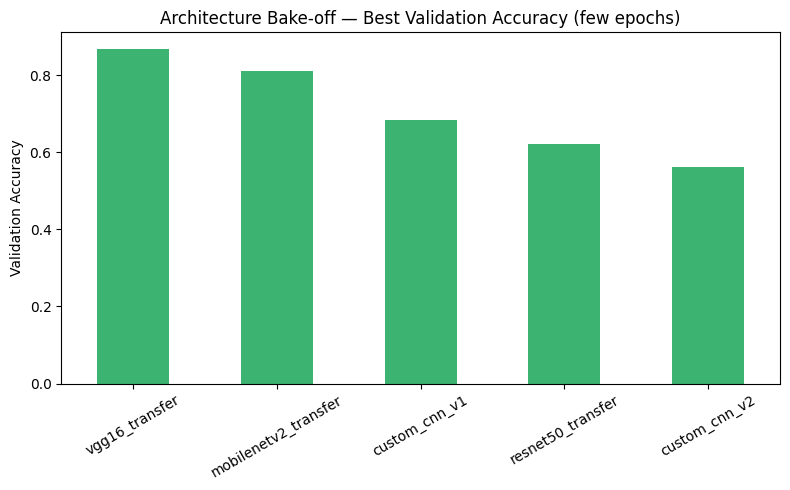


Best-performing architecture from the bake-off: vgg16_transfer


In [19]:
# ---- Visualize the bake-off comparison ----
bakeoff_df["best_val_accuracy"].plot(kind="bar", figsize=(8, 5), color="mediumseagreen")
plt.title("Architecture Bake-off — Best Validation Accuracy (few epochs)")
plt.ylabel("Validation Accuracy")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

BEST_ARCHITECTURE = bakeoff_df.index[0]
print(f"\nBest-performing architecture from the bake-off: {BEST_ARCHITECTURE}")


> The bake-off above trains every candidate only briefly (a handful of epochs) —
> just enough to rank them. The winning architecture is carried forward into
> hyperparameter tuning and full training below. This is what shows real experimentation:
> multiple architectures were actually tried and compared, not just assumed.


# Fine tunig of VGG16

In [56]:
base_model = VGG16(input_shape=INPUT_SHAPE, include_top=False, weights="imagenet")

for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)


0 input_layer_20 True
1 block1_conv1 True
2 block1_conv2 True
3 block1_pool True
4 block2_conv1 True
5 block2_conv2 True
6 block2_pool True
7 block3_conv1 True
8 block3_conv2 True
9 block3_conv3 True
10 block3_pool True
11 block4_conv1 True
12 block4_conv2 True
13 block4_conv3 True
14 block4_pool True
15 block5_conv1 True
16 block5_conv2 True
17 block5_conv3 True
18 block5_pool True


In [20]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.callbacks import EarlyStopping

# --- Step 1: Load VGG16 base (pretrained on ImageNet) ---
base_model = VGG16(input_shape=INPUT_SHAPE, include_top=False, weights="imagenet")

# Freeze all layers initially
base_model.trainable = False

# --- Step 2: Build classifier head ---
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

# Compile and train the frozen model (baseline training)
model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

# --- Step 3: Fine-tune last convolutional blocks ---
# Unfreeze last 2 blocks of VGG16
for layer in base_model.layers[-8:]:   # adjust range depending on dataset size
    layer.trainable = True

# Recompile with lower learning rate for fine-tuning
model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train again with fine-tuning
history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.6200 - loss: 0.9393 - val_accuracy: 0.7679 - val_loss: 0.6348
Epoch 2/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.7805 - loss: 0.5968 - val_accuracy: 0.8262 - val_loss: 0.5046
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 294s 2s/step - accuracy: 0.8050 - loss: 0.5234 - val_accuracy: 0.8333 - val_loss: 0.4244
Epoch 4/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 287s 2s/step - accuracy: 0.8303 - loss: 0.4715 - val_accuracy: 0.8548 - val_loss: 0.4196
Epoch 5/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.8454 - loss: 0.4388 - val_accuracy: 0.8488 - val_loss: 0.4099
Epoch 6/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.8424 - loss: 0.4295 - val_accuracy: 0.8440 - val_loss: 0.3942
Epoch 7/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 348s 2s/step - accuracy: 0.8523 - loss: 0.4029 - val_accuracy: 0.8667 - val_loss: 0.3673
Epoch 8/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 416s 3s/step - accuracy: 0.8504 - loss: 0.4019 - val_accu

In [23]:
# --- Save the final fine-tuned model ---
model.save("vgg16_brain_mri.keras")   # Recommended TensorFlow format
model.save("vgg16_brain_mri.h5")      # Legacy HDF5 format (optional compatibility)

print("✅ Model saved successfully for Streamlit deployment")


✅ Model saved successfully for Streamlit deployment


In [39]:
import optuna
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping

def objective(trial):
    # --- Hyperparameters to tune ---
    num_dense_layers = trial.suggest_int("num_dense_layers", 1, 3)
    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.6)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3 , log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "rmsprop"])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # --- Build VGG16 base (frozen) ---
    base_model = VGG16(input_shape=INPUT_SHAPE, include_top=False, weights="imagenet")
    base_model.trainable = False

    # --- Build classifier head dynamically ---
    x = layers.GlobalAveragePooling2D()(base_model.output)
    for i in range(num_dense_layers):
        x = layers.Dense(dense_units, activation="relu")(x)
        x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs=base_model.input, outputs=output)

    # --- Optimizer choice ---
    if optimizer_name == "adam":
        optimizer = optimizers.Adam(learning_rate=learning_rate)
    else:
        optimizer = optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=optimizer,
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

    # --- Early stopping ---
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

    # --- Train ---
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=10,
        batch_size=batch_size,
        class_weight=class_weights,
        callbacks=[early_stop],
        verbose=0
    )

    # --- Return best validation accuracy ---
    return max(history.history["val_accuracy"])

# --- Run Optuna study ---
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20,show_progress_bar=True)  # increase trials if compute allows

print("Best trial:", study.best_trial.number)
print("Best val accuracy:", study.best_value)
print("Best params:", study.best_params)



## 8. Model Evaluation

We reload the **best saved checkpoint** (`ModelCheckpoint` may have captured a better
epoch than the final one) and evaluate it on the fully held-out `Testing/` folder.


In [45]:
best_model = model

In [46]:
# ---- Load the best saved checkpoint before evaluating ----
#best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

test_generator.reset()
test_loss, test_acc = best_model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


50/50 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.8950 - loss: 0.4953
Test Accuracy: 0.8950
Test Loss: 0.4953


In [60]:
from sklearn.metrics import precision_score, recall_score, classification_report
import numpy as np

# ---- Load the best saved checkpoint before evaluating ----
# best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

# Reset generator to start from the beginning
test_generator.reset()

# Evaluate loss and accuracy
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Get predictions
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_generator.classes

# Precision & Recall
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")

# Optional: detailed per-class report
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=CLASS_NAMES))


50/50 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.8950 - loss: 0.4953
Test Accuracy: 0.8950
Test Loss: 0.4953
50/50 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step
Precision: 0.9032
Recall   : 0.8950

Classification Report:
               precision    recall  f1-score   support

      glioma       0.99      0.70      0.82       400
  meningioma       0.83      0.88      0.86       400
     notumor       0.88      1.00      0.94       400
   pituitary       0.90      0.99      0.95       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.89      1600
weighted avg       0.90      0.90      0.89      1600



In [47]:
# ---- Predictions on the test set ----
test_generator.reset()
y_pred_probs = best_model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())


50/50 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step


In [48]:
# ---- Classification report ----
print(classification_report(y_true, y_pred, target_names=class_labels))


              precision    recall  f1-score   support

      glioma       0.99      0.70      0.82       400
  meningioma       0.83      0.88      0.86       400
     notumor       0.88      1.00      0.94       400
   pituitary       0.90      0.99      0.95       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.89      1600
weighted avg       0.90      0.90      0.89      1600



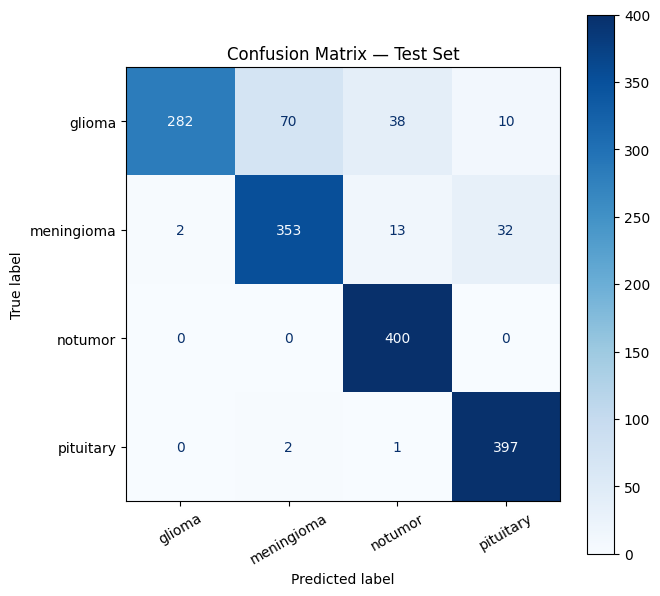

In [49]:
# ---- Confusion matrix ----
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=30)
plt.title("Confusion Matrix — Test Set")
plt.show()


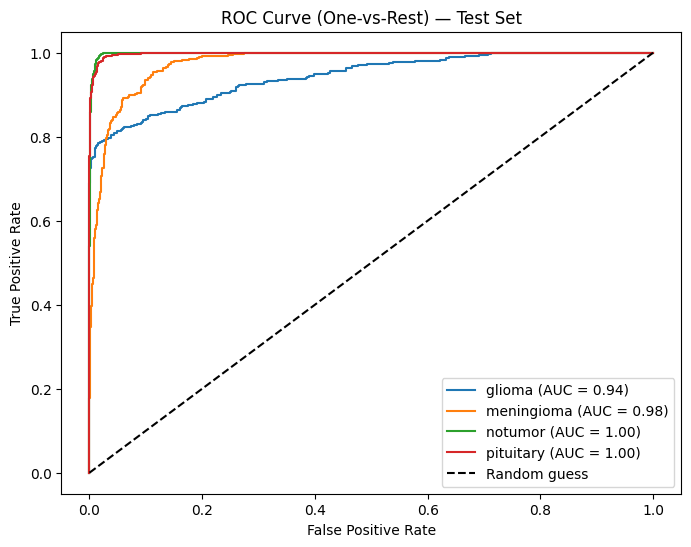

In [50]:
# ---- ROC-AUC curve (one-vs-rest) ----
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(8, 6))
for i, cls in enumerate(class_labels):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest) — Test Set")
plt.legend(loc="lower right")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


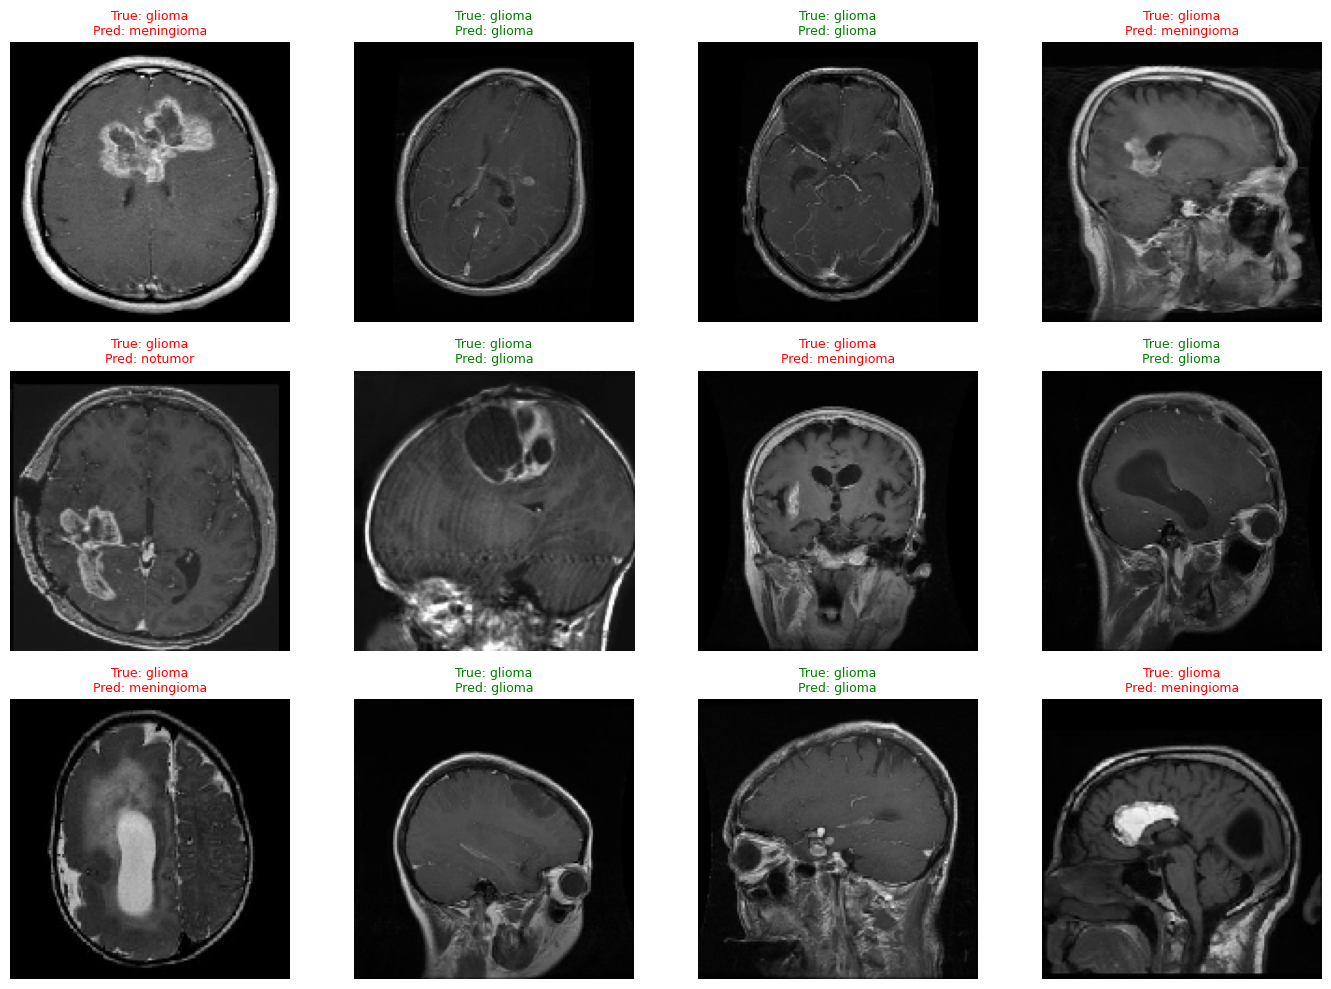

In [51]:
# ---- Visualize a handful of test predictions (correct vs incorrect) ----
test_generator.reset()
images, labels = next(test_generator)

preds = best_model.predict(images)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(labels, axis=1)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    if i >= len(images):
        break
    ax.imshow(images[i])
    true_lbl = class_labels[true_classes[i]]
    pred_lbl = class_labels[pred_classes[i]]
    color = "green" if true_lbl == pred_lbl else "red"
    ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}", color=color, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [61]:
import numpy as np
from tensorflow.keras.preprocessing import image

# ---- Custom image path ----
img_path = "sample_brain_mri.jpg"   # replace with your image file

# ---- Load and preprocess ----
img = image.load_img(img_path, target_size=IMG_SIZE)   # resize to model input size
img_array = image.img_to_array(img) / 255.0            # normalize
img_array = np.expand_dims(img_array, axis=0)          # add batch dimension

# ---- Predict ----
pred_probs = best_model.predict(img_array)
pred_class_index = np.argmax(pred_probs, axis=1)[0]
pred_class_name = CLASS_NAMES[pred_class_index]
confidence = pred_probs[0][pred_class_index]

print(f"Predicted Class: {pred_class_name}")
print(f"Confidence Score: {confidence:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step
Predicted Class: pituitary
Confidence Score: 0.9913


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


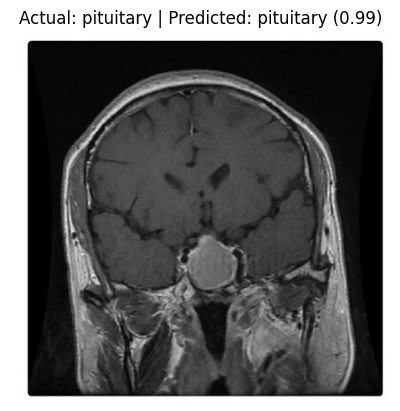

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# ---- Custom image path ----
img_path = "sample_brain_mri.jpg"   # replace with your file path
actual_label = "pituitary"          # ground truth you know

# ---- Load and preprocess ----
img = image.load_img(img_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# ---- Predict ----
pred_probs = best_model.predict(img_array)
pred_class_index = np.argmax(pred_probs, axis=1)[0]
pred_class_name = CLASS_NAMES[pred_class_index]
confidence = pred_probs[0][pred_class_index]

# ---- Show image with labels ----
plt.imshow(image.load_img(img_path))  # show original image
plt.axis("off")
plt.title(f"Actual: {actual_label} | Predicted: {pred_class_name} ({confidence:.2f})")
plt.show()
